/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: III. Corrente.wav  |  sr=44100  |  20.0s  |  882000 samples


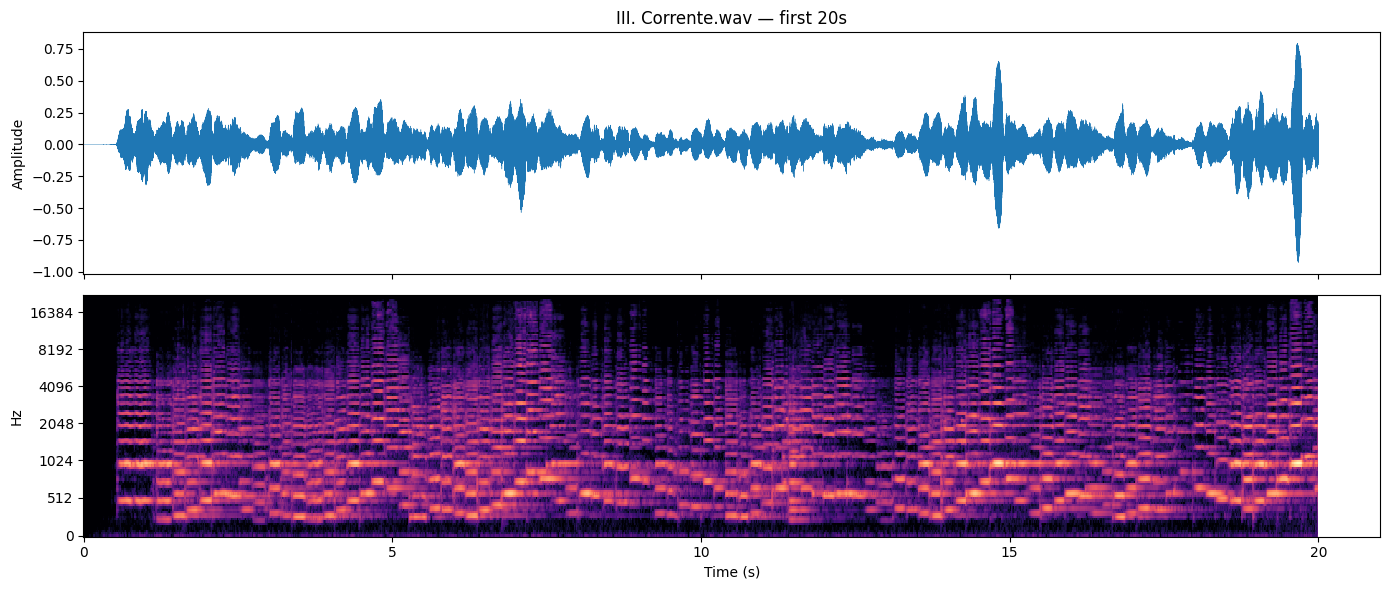

In [1]:
import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

PROJECT_ROOT = Path("../../").resolve()
# Load first 20 seconds
audio_path = PROJECT_ROOT / "data" / "raw" / "solo_violin" / "III. Corrente.wav"
y, sr = librosa.load(str(audio_path), sr=None, duration=20.0)
print(f"Loaded: {audio_path.name}  |  sr={sr}  |  {len(y)/sr:.1f}s  |  {len(y)} samples")

# Plot waveform + spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Waveform
t = np.arange(len(y)) / sr
axes[0].plot(t, y, linewidth=0.3)
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"{audio_path.name} — first 20s")

# Mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_ylabel("Hz")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# Playback
ipd.Audio(y, rate=sr)

In [4]:
import os
import time

import gin
import soundfile as sf
import tensorflow.compat.v2 as tf
import ddsp
import ddsp.training

# Add src to path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from feature_utils import compute_features, trim_features
from timbre_transfer import TimbreTransfer
from utils import DEFAULT_SAMPLE_RATE

# Resample to 16 kHz (DDSP default) and compute features
target_sr = DEFAULT_SAMPLE_RATE
y_16k = librosa.resample(y, orig_sr=sr, target_sr=target_sr) if sr != target_sr else y
audio = y_16k[np.newaxis, :]
audio_features = compute_features(audio)

# Load model
model_path = str(PROJECT_ROOT / "artifacts" / "solo_instrument")
tt = TimbreTransfer.from_path(model_path)
tt.load()

# Trim features to model dimensions and run inference
# audio_features = trim_features(audio_features, tt.time_steps, tt.n_samples)
audio_gen = tt.synthesize(audio_features)

# Save output
output_path = str(PROJECT_ROOT / "artifacts" / "playground_output.wav")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
sf.write(output_path, audio_gen, target_sr)
print(f"Saved to: {output_path}")

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)
/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/crepe/core.py:209: RuntimeWarning: invalid value encountered in divide
  frames /= np.std(frames, axis=1)[:, np.newaxis]
/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Saved to: /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/playground_output.wav


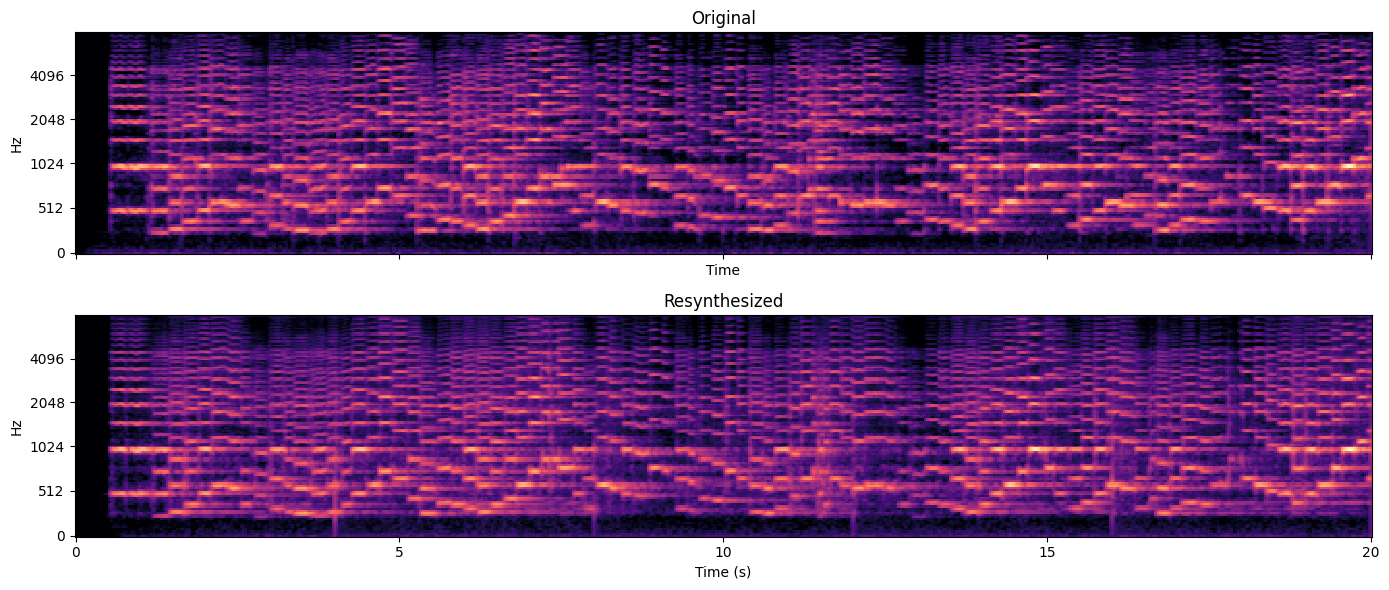

Original:


Resynthesized:


In [5]:
# Compare original vs resynthesized
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Original
S_orig = librosa.feature.melspectrogram(y=y_16k, sr=target_sr, n_mels=128)
librosa.display.specshow(
    librosa.power_to_db(S_orig, ref=np.max),
    sr=target_sr, x_axis="time", y_axis="mel", ax=axes[0],
)
axes[0].set_title("Original")
axes[0].set_ylabel("Hz")

# Resynthesized
S_gen = librosa.feature.melspectrogram(y=audio_gen, sr=target_sr, n_mels=128)
librosa.display.specshow(
    librosa.power_to_db(S_gen, ref=np.max),
    sr=target_sr, x_axis="time", y_axis="mel", ax=axes[1],
)
axes[1].set_title("Resynthesized")
axes[1].set_ylabel("Hz")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# Playback
print("Original:")
display(ipd.Audio(y_16k, rate=target_sr))
print("Resynthesized:")
display(ipd.Audio(audio_gen, rate=target_sr))